In [1]:
# ================================================================
# HyperCLAP — Validation 3 : Scale 50 Classes (ESC-50 complet)
#
# Objectif : tester si le mécanisme tient quand on passe de
# 10 classes (400 clips) à 50 classes (2000 clips).
#
# Protocole identique à S11 — seul le corpus change.
# ================================================================

In [2]:
!pip install -q datasets soundfile librosa
print("done")

done


In [3]:
import numpy as np
import librosa
import random
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

CFG = dict(
    n_mels=128, n_fft=1024, hop_length=512,
    k=4, d=64, tau=0.1, lr=3e-4, batch_size=32,
)
TARGET_T   = 128
N_CLASSES  = 50    # ← toutes les classes ESC-50
EPOCHS_P1  = 60
EPOCHS_P2  = 40
N_MIX_TEST = 400

Device: cuda


In [4]:
print("Loading ESC-50 complet (50 classes, 2000 clips)...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]

def extract_logmel(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    mel = librosa.feature.melspectrogram(
        y=w, sr=sr, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    return librosa.power_to_db(mel, ref=np.max)

def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32)

def pool_mel(t, T=TARGET_T):
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[0], T)).squeeze(0)

def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w

print("Pre-computing log-mel spectrograms...")
all_logmels = []; all_waveforms = []; all_categories = []
for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel(sample))
    all_waveforms.append((sample["audio"]["array"], sample["audio"]["sampling_rate"]))
    all_categories.append(sample["category"])
    if (i+1) % 400 == 0: print(f"  {i+1}/{len(esc50_train)}")

categories    = sorted(set(all_categories))
cat2idx       = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
N_total       = len(all_logmels)
print(f"Done. {N_total} clips, {N_CLASSES} classes\n")

Loading ESC-50 complet (50 classes, 2000 clips)...


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Pre-computing log-mel spectrograms...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done. 2000 clips, 50 classes



In [5]:
# ── Architecture ────────────────────────────────────────────────
class SubspaceEncoder(nn.Module):
    def __init__(self, d=64, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256, d*k))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x.unsqueeze(1)).view(B, -1)
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z); return Z

class PointEncoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1,16,3,padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4,4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024,256), nn.GELU(), nn.Linear(256,d))
    def forward(self, x):
        B = x.shape[0]
        return F.normalize(self.proj(self.cnn(x.unsqueeze(1)).view(B,-1)), dim=-1)

In [6]:
# ── Losses ───────────────────────────────────────────────────────
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]

def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]

def infonce_subspace(Za, Zp, tau=0.1):
    B = Za.shape[0]
    return F.cross_entropy(subspace_sim_matrix(Za,Zp)/tau, torch.arange(B,device=Za.device))

def infonce_cosine(za, zp, tau=0.1):
    B = za.shape[0]
    return F.cross_entropy(torch.mm(za,zp.T)/tau, torch.arange(B,device=za.device))

def alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list, margin=0.1):
    pos = (subspace_sim_batch(Z_mix,Z_a) + subspace_sim_batch(Z_mix,Z_b)) / 2
    neg = torch.stack([subspace_sim_batch(Z_mix,Zn) for Zn in Z_neg_list],dim=1).max(1).values
    return F.relu(margin + neg - pos).mean(), pos.mean().item(), neg.mean().item()

In [7]:
# ── Datasets ─────────────────────────────────────────────────────
class PairDataset(Dataset):
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label

class MixtureDataset(Dataset):
    def __init__(self, logmels, waveforms, label_ids, n_neg=4):
        self.logmels = logmels; self.waveforms = waveforms
        self.label_ids = label_ids; self.n_neg = n_neg
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())
    def __len__(self): return len(self.logmels)
    def _t(self, idx): return pool_mel(logmel_to_tensor(self.logmels[idx]))
    def _mix_t(self, wa, sra, wb):
        mix = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        lm  = librosa.feature.melspectrogram(y=mix, sr=sra,
            n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        return pool_mel(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))
    def __getitem__(self, idx):
        a_lbl  = self.label_ids[idx]
        others = [c for c in self.all_classes if c != a_lbl]
        b_idx  = random.choice(self.by_class[random.choice(others)])
        wa, sra = self.waveforms[idx]; wb, _ = self.waveforms[b_idx]
        negs = [random.choice(self.by_class[random.choice(
                [c for c in self.all_classes
                 if c not in [a_lbl, self.label_ids[b_idx]]])])
                for _ in range(self.n_neg)]
        return self._mix_t(wa, sra, wb), self._t(idx), self._t(b_idx), \
               torch.stack([self._t(n) for n in negs]), idx, b_idx

In [8]:
# ── Entraînement ─────────────────────────────────────────────────
sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
pt_model  = PointEncoder(d=CFG["d"]).to(DEVICE)

pair_dl = DataLoader(PairDataset(all_logmels, all_label_ids),
                     batch_size=CFG["batch_size"], shuffle=True, drop_last=True)
mix_dl  = DataLoader(MixtureDataset(all_logmels, all_waveforms, all_label_ids),
                     batch_size=CFG["batch_size"], shuffle=True, drop_last=True)

sub_opt = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
pt_opt  = torch.optim.Adam(pt_model.parameters(),  lr=CFG["lr"])

print(f"PHASE 1 — InfoNCE ({EPOCHS_P1} epochs) — 50 classes")
sub_model.train(); pt_model.train()
for epoch in range(EPOCHS_P1):
    ts = 0.0; tp = 0.0; nb = 0
    for anc, pos, _ in pair_dl:
        anc = anc.to(DEVICE); pos = pos.to(DEVICE)
        sub_opt.zero_grad()
        ls = infonce_subspace(sub_model(anc), sub_model(pos), CFG["tau"])
        ls.backward(); sub_opt.step()
        pt_opt.zero_grad()
        lp = infonce_cosine(pt_model(anc), pt_model(pos), CFG["tau"])
        lp.backward(); pt_opt.step()
        ts += ls.item(); tp += lp.item(); nb += 1
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P1}  sub={ts/nb:.4f}  pt={tp/nb:.4f}")

print(f"\nPHASE 2 — Acoustic alignment ({EPOCHS_P2} epochs)")
sub_opt2 = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"]/5)
sub_model.train()
for epoch in range(EPOCHS_P2):
    tot = 0.0; nb = 0
    for mix_t, src_a, src_b, neg_ts, ai, bi in mix_dl:
        mix_t = mix_t.to(DEVICE); src_a = src_a.to(DEVICE)
        src_b = src_b.to(DEVICE); neg_ts = neg_ts.to(DEVICE)
        sub_opt2.zero_grad()
        Z_mix = sub_model(mix_t)
        with torch.no_grad():
            Z_a = sub_model(src_a); Z_b = sub_model(src_b)
            B, nn_, H, W = neg_ts.shape
            Zn = sub_model(neg_ts.view(B*nn_, H, W))
            Z_neg_list = [Zn[i::nn_] for i in range(nn_)]
        loss, ps, ns = alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list)
        loss.backward(); sub_opt2.step()
        tot += loss.item(); nb += 1
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P2}  align={tot/nb:.4f}  "
              f"pos={ps:.4f}  neg={ns:.4f}")

PHASE 1 — InfoNCE (60 epochs) — 50 classes
  Epoch 10/60  sub=1.4161  pt=1.3630
  Epoch 20/60  sub=0.8616  pt=0.8106
  Epoch 30/60  sub=0.6430  pt=0.6045
  Epoch 40/60  sub=0.5450  pt=0.5246
  Epoch 50/60  sub=0.5196  pt=0.4922
  Epoch 60/60  sub=0.4802  pt=0.4610

PHASE 2 — Acoustic alignment (40 epochs)
  Epoch 10/40  align=0.0116  pos=0.4392  neg=0.2139
  Epoch 20/40  align=0.0086  pos=0.4467  neg=0.1644
  Epoch 30/40  align=0.0064  pos=0.4783  neg=0.1901
  Epoch 40/40  align=0.0057  pos=0.4769  neg=0.1679



Pre-computing embeddings (2000 clips)...
mat_sub=(2000, 64, 4)  mat_pt=(2000, 64)

EXPERIMENT V3: ESC-50 Complet — 50 classes, 2000 clips

  400 queries évaluées

  k        Décomposition   Direct sub      Point         Δ
  ───────────────────────────────────────────────────────
  @1              0.1600       0.0175     0.0175  +0.1425 ✓
  @2              0.1600       0.0525     0.0225  +0.1375 ✓
  @5              0.1600       0.1250     0.0550  +0.1050 ✓
  @10             0.1600       0.1900     0.0700  +0.0900 ✓

  Both classes (@2):
    Décomposition  : 0.1600
    Point encoder  : 0.0225
    Random baseline: 0.0400  (beaucoup plus bas sur 50 classes)
    Ratio          : 7.1×

  Setup                            Décomp    Point    Ratio    Random
  ────────────────────────────────────────────────────────────
  S11  10 classes (400 clips)      0.6516   0.1203     5.4×    0.2000
  V3   50 classes (2000 clips)     0.1600   0.0225     7.1×    0.0400

Figure saved → hyperclap_scale50.png

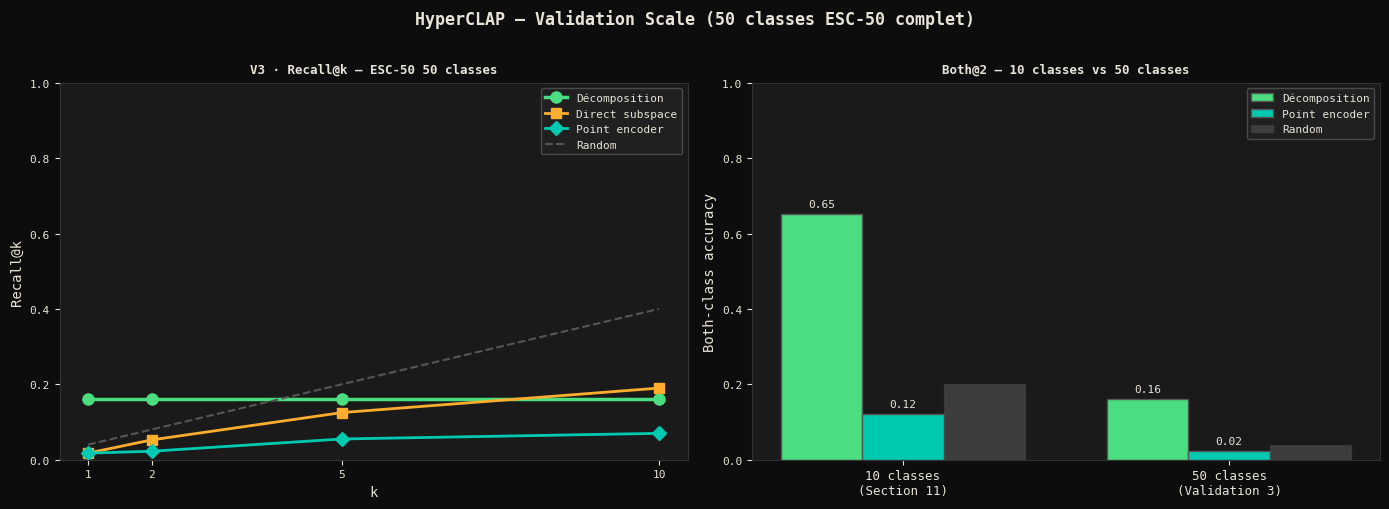

In [9]:
# ── Évaluation ───────────────────────────────────────────────────
print("\nPre-computing embeddings (2000 clips)...")
sub_model.eval(); pt_model.eval()
emb_sub = []; emb_pt = []
with torch.no_grad():
    for lm in all_logmels:
        t = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())
mat_sub = np.stack(emb_sub); mat_pt = np.stack(emb_pt)
print(f"mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

def batch_sub_sim(z, mat):
    M = np.einsum("dp,ndq->npq", z, mat)
    return (M**2).sum(axis=(1,2)) / z.shape[1]

def batch_cos_sim(v, mat):
    return (mat @ v) / (np.linalg.norm(mat, axis=1) * np.linalg.norm(v) + 1e-8)

def orth_proj(Z_mix, Z_ref):
    P = np.eye(Z_mix.shape[0]) - Z_ref @ Z_ref.T
    Q, _ = np.linalg.qr(P @ Z_mix)
    return Q[:, :Z_mix.shape[1]]

def iterative_decomp(Z_mix, mat, ei, ej):
    s1 = batch_sub_sim(Z_mix, mat); s1[ei] = s1[ej] = -np.inf
    p1 = int(np.argmax(s1))
    s2 = batch_sub_sim(orth_proj(Z_mix, mat[p1]), mat)
    s2[ei] = s2[ej] = s2[p1] = -np.inf
    return p1, int(np.argmax(s2))

print(f"{'='*65}")
print(f"EXPERIMENT V3: ESC-50 Complet — 50 classes, {N_total} clips")
print(f"{'='*65}")

KS = [1, 2, 5, 10]
hits_decomp = defaultdict(int)
hits_direct = defaultdict(int)
hits_pt     = defaultdict(int)
both_decomp = 0; both_pt = 0; n_q = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_total-1); j = random.randint(0, N_total-1)
    if i == j: continue
    li = all_label_ids[i]; lj = all_label_ids[j]
    wa, sra = all_waveforms[i]; wb, _ = all_waveforms[j]
    mix = normalize_w(wa) + normalize_w(wb)
    lm_mix = librosa.feature.melspectrogram(y=mix, sr=sra,
        n_fft=CFG["n_fft"], hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_mel(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()
    ss = batch_sub_sim(Z_mix, mat_sub); ss[[i,j]] = -np.inf
    sp = batch_cos_sim(v_mix, mat_pt);  sp[[i,j]] = -np.inf
    ranked_sub = [all_label_ids[idx] for idx in np.argsort(-ss)]
    ranked_pt  = [all_label_ids[idx] for idx in np.argsort(-sp)]
    p1, p2 = iterative_decomp(Z_mix, mat_sub, i, j)
    dl = {all_label_ids[p1], all_label_ids[p2]}
    n_q += 1
    found_d = li in dl and lj in dl
    for k in KS:
        ts = set(ranked_sub[:k]); tp = set(ranked_pt[:k])
        if li in ts and lj in ts: hits_direct[k] += 1
        if li in tp and lj in tp: hits_pt[k]     += 1
        if found_d:               hits_decomp[k] += 1
    if found_d: both_decomp += 1
    if li in set(ranked_pt[:2]) and lj in set(ranked_pt[:2]): both_pt += 1

print(f"\n  {n_q} queries évaluées\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ':>8}")
print("  " + "─" * 55)
recalls = {}
for k in KS:
    r_d=hits_decomp[k]/n_q; r_s=hits_direct[k]/n_q; r_p=hits_pt[k]/n_q
    recalls[k]=dict(decomp=r_d,direct=r_s,pt=r_p)
    sym = "✓" if r_d > r_p else "✗"
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+7.4f} {sym}")

v3_decomp = both_decomp/n_q; v3_pt = both_pt/n_q
print(f"\n  Both classes (@2):")
print(f"    Décomposition  : {v3_decomp:.4f}")
print(f"    Point encoder  : {v3_pt:.4f}")
print(f"    Random baseline: {2/N_CLASSES:.4f}  (beaucoup plus bas sur 50 classes)")
print(f"    Ratio          : {v3_decomp/(v3_pt+1e-8):.1f}×")

# Tableau comparatif
S11 = (0.6516, 0.1203, 10)
print(f"\n  {'Setup':<30} {'Décomp':>8} {'Point':>8}  {'Ratio':>7}  {'Random':>8}")
print("  " + "─" * 60)
print(f"  {'S11  10 classes (400 clips)':<30} {S11[0]:>8.4f} {S11[1]:>8.4f}  {S11[0]/S11[1]:>6.1f}×  {2/S11[2]:>8.4f}")
print(f"  {'V3   50 classes (2000 clips)':<30} {v3_decomp:>8.4f} {v3_pt:>8.4f}  {v3_decomp/(v3_pt+1e-8):>6.1f}×  {2/N_CLASSES:>8.4f}")

# Figure
DARK="#0d0d0d"; LIGHT="#e8e4d9"; GREEN="#4ade80"; CYAN="#00c9b1"; AMBER="#ffad2f"
plt.rcParams.update({"text.color":LIGHT,"axes.labelcolor":LIGHT,
                     "xtick.color":LIGHT,"ytick.color":LIGHT,
                     "axes.edgecolor":"#333333","font.family":"monospace"})
def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a"); ax.set_title(title,color=LIGHT,fontsize=9,pad=7,fontweight="bold")
    ax.tick_params(colors=LIGHT,labelsize=8); ax.spines[:].set_color("#333333")

fig, axes = plt.subplots(1, 2, figsize=(14, 5)); fig.patch.set_facecolor(DARK)

ax = axes[0]; ax_style(ax, "V3 · Recall@k — ESC-50 50 classes")
ax.plot(KS,[recalls[k]["decomp"] for k in KS],"o-",color=GREEN,lw=2.5,ms=8,label="Décomposition")
ax.plot(KS,[recalls[k]["direct"] for k in KS],"s-",color=AMBER,lw=2,ms=7,label="Direct subspace")
ax.plot(KS,[recalls[k]["pt"]     for k in KS],"D-",color=CYAN, lw=2,ms=7,label="Point encoder")
ax.plot(KS,[2*k/N_CLASSES for k in KS],"--",color="#555",lw=1.5,label="Random")
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(KS); ax.set_ylim(0,1.0)
ax.legend(fontsize=8,facecolor="#222",edgecolor="#555",labelcolor=LIGHT)

ax2 = axes[1]; ax_style(ax2, "Both@2 — 10 classes vs 50 classes")
setups = ["10 classes\n(Section 11)", "50 classes\n(Validation 3)"]
dv = [S11[0], v3_decomp]; pv = [S11[1], v3_pt]
rv = [2/S11[2], 2/N_CLASSES]
x = np.arange(2); w = 0.25
ax2.bar(x-w,  dv, w, color=GREEN,  edgecolor="#555", label="Décomposition")
ax2.bar(x,    pv, w, color=CYAN,   edgecolor="#555", label="Point encoder")
ax2.bar(x+w,  rv, w, color="#555", edgecolor="#444", label="Random", alpha=0.6)
ax2.set_xticks(x); ax2.set_xticklabels(setups, fontsize=9)
ax2.set_ylabel("Both-class accuracy"); ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=8,facecolor="#222",edgecolor="#555",labelcolor=LIGHT)
for i_,(d,p) in enumerate(zip(dv,pv)):
    ax2.text(i_-w, d+0.02, f"{d:.2f}", ha="center", color=LIGHT, fontsize=8)
    ax2.text(i_,   p+0.02, f"{p:.2f}", ha="center", color=LIGHT, fontsize=8)

fig.suptitle("HyperCLAP — Validation Scale (50 classes ESC-50 complet)",
             color=LIGHT, fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/hyperclap_scale50.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("\nFigure saved → hyperclap_scale50.png")
plt.show()